__Notebook Structure__

- Imports
- Define equation
- Test normal training
- Test normal training with extra collocation points around x = 0 error points
- Test Causal training on Burgers eqn

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import time

from src.model import PINN
from src.data import (
    generate_boundary_points,
    generate_initial_points,
    generate_collocation_points,
    generate_collocation_points_shock)

from src.train import train_pinn
from src.evaluate import relativeERROR

# Set default data type to float32
torch.set_default_dtype(torch.float)

# PyTorch random number generator
torch.manual_seed(1234)

# Numpy random number generator
np.random.seed(1234)

Burger's Equation
$$u_t + u \cdot u_x = \nu \, u_{xx}, \quad x \in [-1,1],\ t \in [0,1]$$
$$u(-1,t) = u(1,t) = 0, \qquad u(x,0) = -\sin(\pi x)$$
Non-linear time dependant behavior.
No closed form analytic solution.


In [4]:
def Burgers_initial_function(x):
    return -torch.sin(torch.pi*x)

x_bc, y_bc = generate_boundary_points(100)
x_ic, y_ic = generate_initial_points(1000, Burgers_initial_function)
col_points = generate_collocation_points(10000)
mu = 0.01/torch.pi

def Burgers_equation(g, u, derivs, mu = mu):
    x, t = g[:,[0]], g[:,[1]]
    return derivs['u_t'] + u*derivs['u_x'] - mu*derivs['u_xx']

In [5]:
pinn = PINN()
history, final_loss = train_pinn(pinn, x_bc, y_bc, x_ic, y_ic, col_points,
    var_names=['x', 't'],
    PDE_residual_fn=Burgers_equation, epochs = 10000)


/Users/willcowling/Library/Python/3.9/lib/python/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = float(closure())


Relative error: 0.229760


Text(0, 0.5, 't')

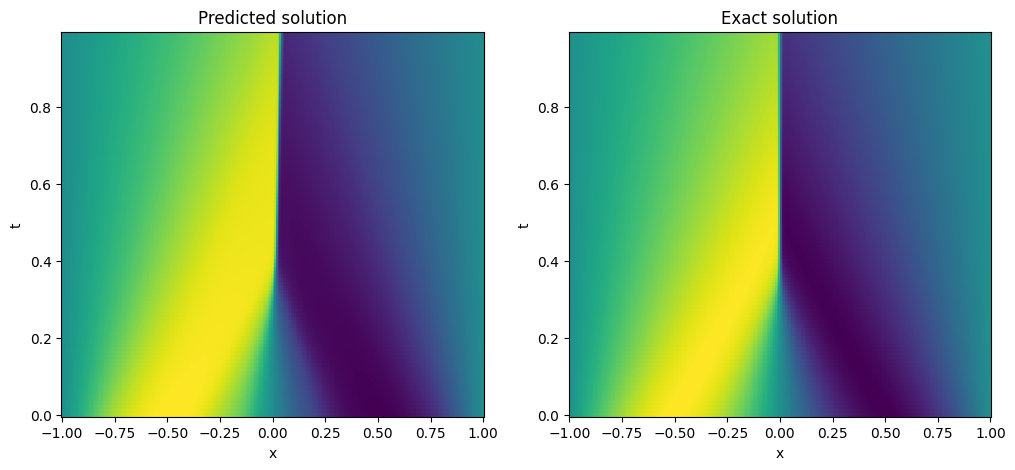

In [6]:
# Heat map comparison: PINN vs exact benchmark solution

import scipy.io
import numpy as np

# Import exact grid + solution
data = scipy.io.loadmat('data/burgers_shock.mat')
x_exact = data['x'].flatten()                         # Shape: (256,)
t_exact = data['t'].flatten()                          # Shape: (100,)
u_sol = (data['usol']).astype(np.float32)        # Shape: (256, 100)

# Build an empty grid using the exact grid's coordinates, so predicted and
# exact line up point-for-point with no interpolation needed
X, T = np.meshgrid(x_exact, t_exact, indexing='ij')     # shape (256, 100)
grid = torch.tensor(np.stack([X.flatten(), T.flatten()], axis=1), dtype=torch.float32)

# Act the PINN on that grid
with torch.no_grad():
    predicted_values = pinn(grid).numpy().reshape(X.shape)

# Relative error
relative_error = relativeERROR(torch.tensor(predicted_values), torch.tensor(u_sol))
print(f"Relative error: {relative_error.item():.6f}")

# Compare side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].pcolormesh(X, T, predicted_values)
axs[0].set_title('Predicted solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X, T, u_sol)
axs[1].set_title('Exact solution')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

Text(0, 0.5, 't')

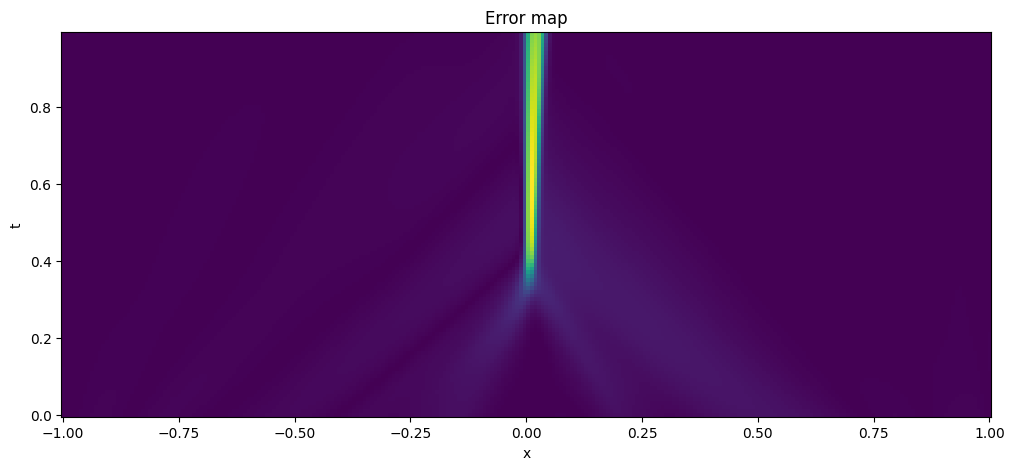

In [7]:
# Create Error Heatmap Comparing Relative Error with/without LBFGS
fig, ax = plt.subplots(figsize=(12, 5))
ax.pcolormesh(X,T,np.abs(predicted_values-u_sol).reshape(X.shape))
ax.set_title('Error map')
ax.set_xlabel('x')
ax.set_ylabel('t')

The error is localised and the model needs to fit points close to x = 0 better. To solve this I will attempt training the model on more collocation points closer to x = 0.

In [8]:
col_points_shock = generate_collocation_points_shock(8000,2000, 0.02)

Relative error: 0.676646


Text(0, 0.5, 't')

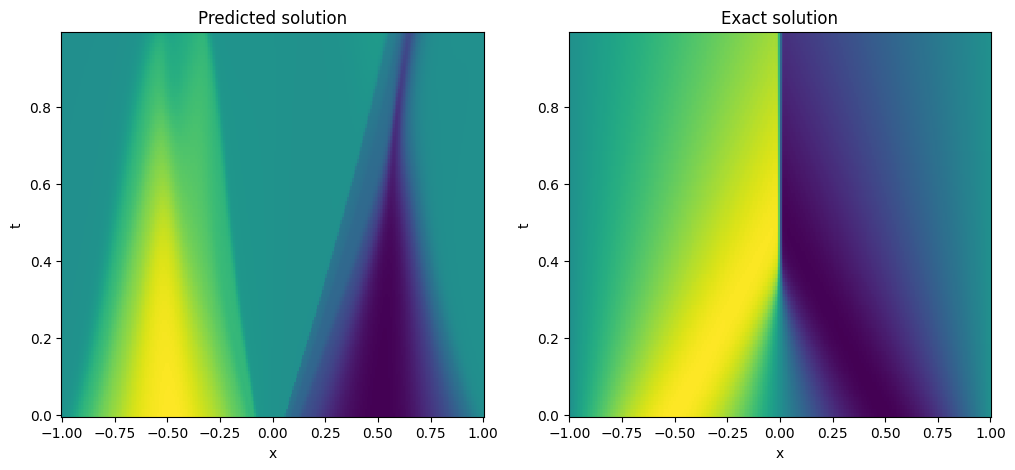

In [9]:
pinn = PINN()
history, final_loss = train_pinn(pinn, x_bc, y_bc, x_ic, y_ic, col_points_shock,
    var_names=['x', 't'],
    PDE_residual_fn=Burgers_equation, epochs = 10000)
# Act the PINN on that grid
with torch.no_grad():
    predicted_values = pinn(grid).numpy().reshape(X.shape)

# Relative error
relative_error = relativeERROR(torch.tensor(predicted_values), torch.tensor(u_sol))
print(f"Relative error: {relative_error.item():.6f}")

# Compare side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].pcolormesh(X, T, predicted_values)
axs[0].set_title('Predicted solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X, T, u_sol)
axs[1].set_title('Exact solution')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

This clearly has not worked. I will now attempt to apply the causal training model to this equation.

In [10]:
# Import PINN model and training functions from source
from src.model_causal import PINN
from src.data import (
    generate_boundary_points,
    generate_initial_points,
    generate_collocation_points)
from src.train_causal import train_pinn_causal

Relative error: 0.053973


Text(0, 0.5, 't')

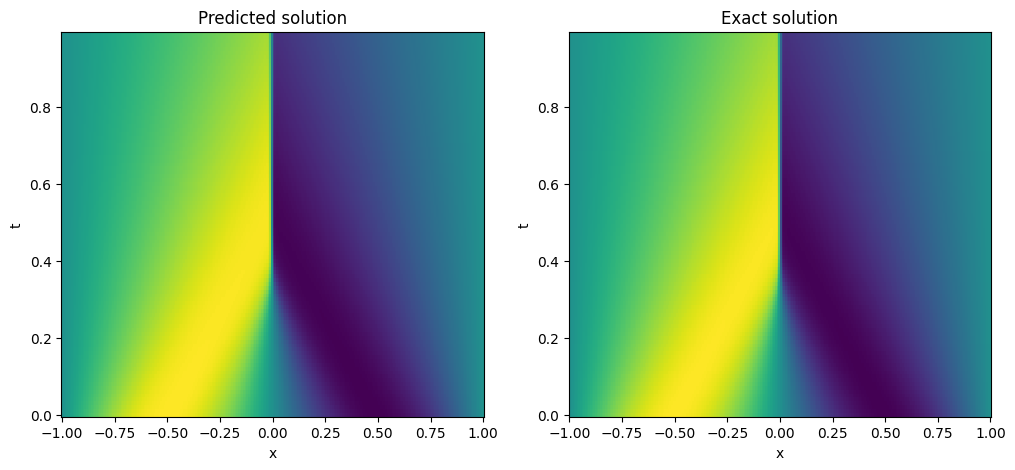

In [21]:
pinn = PINN()
history, final_loss = train_pinn_causal(pinn, x_bc, y_bc, x_ic, y_ic, col_points,
    var_names=['x', 't'],
    PDE_residual_fn=Burgers_equation, epochs = 10000, eps=0.2, n_buckets= 10)
# Act the PINN on that grid
with torch.no_grad():
    predicted_values = pinn(grid).numpy().reshape(X.shape)

# Relative error
relative_error = relativeERROR(torch.tensor(predicted_values), torch.tensor(u_sol))
print(f"Relative error: {relative_error.item():.6f}")

# Compare side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].pcolormesh(X, T, predicted_values)
axs[0].set_title('Predicted solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X, T, u_sol)
axs[1].set_title('Exact solution')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

I have noticed that the relative error results in the above cell have large varience. The code below runs multiple seeds and takes an average. This will allow us to see the true nature of our relative errors over multiple causal training runs. 

In [23]:
results = []
for seed in range(5):
    torch.manual_seed(seed)
    pinn = PINN()
    history, final_loss = train_pinn_causal(pinn, x_bc, y_bc, x_ic, y_ic, col_points,
        var_names=['x', 't'], PDE_residual_fn=Burgers_equation,
        epochs=10000, eps=0.2, n_buckets=10)
    with torch.no_grad():
        predicted_values = pinn(grid).numpy().reshape(X.shape)
    relative_error = relativeERROR(torch.tensor(predicted_values), torch.tensor(u_sol))
    results.append(relative_error.item())
    print(f"Seed {seed}: {relative_error.item():.4f}")

print(f"Mean: {np.mean(results):.4f}, Std: {np.std(results):.4f}")

Seed 0: 0.0987
Seed 1: 0.1987
Seed 2: 0.0678
Seed 3: 0.0237
Seed 4: 0.4167
Mean: 0.1611, Std: 0.1401


In [25]:
best_seed = 3
torch.manual_seed(best_seed)

pinn = PINN()
history, final_loss = train_pinn_causal(pinn, x_bc, y_bc, x_ic, y_ic, col_points,
        var_names=['x', 't'], PDE_residual_fn=Burgers_equation,
        epochs=10000, eps=0.2, n_buckets=10)
with torch.no_grad():
    predicted_values = pinn(grid).numpy().reshape(X.shape)
relative_error = relativeERROR(torch.tensor(predicted_values), torch.tensor(u_sol))
print(f"Relative error: {relative_error.item():.6f}")


Relative error: 0.023723


Text(0, 0.5, 't')

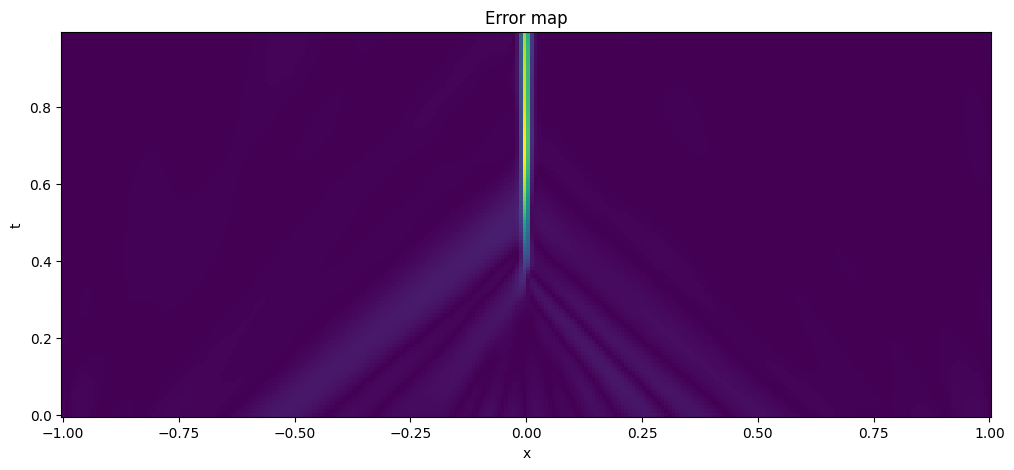

In [26]:
# Create Error Heatmap Comparing Relative Error with/without LBFGS
fig, ax = plt.subplots(figsize=(12, 5))
ax.pcolormesh(X,T,np.abs(predicted_values-u_sol).reshape(X.shape))
ax.set_title('Error map')
ax.set_xlabel('x')
ax.set_ylabel('t')

Causal training has worked remarkably well for specific seeds (achieving as low as a relative 2.7% error) on the Burgers equation. This is likely due to the 'shock' only appearing at t~0.3 seconds. The model is able to train on the smooth function before the discontinuity arises. However, many seeds do not work as well. This is shown by Mean: 0.1611, Std: 0.1401. This is most likely due to shock-forming nonlinear PDEs having harder optimization landscapes than the smooth diffusion cases — different random initializations can land in very different local minima within the landscape. 

In [27]:
from src.visualise import animate_solution
from IPython.display import HTML

# Run animation predicted
fig, anim = animate_solution(X, T, predicted_values, title="Burgers' Equation Predicted", save_path = "Burgers_predicted.gif")
HTML(anim.to_jshtml())

fig, anim = animate_solution(X, T, u_sol, title="Burgers' Equation Exact", save_path = "Burgers_exact.gif")
HTML(anim.to_jshtml())